<a href="https://colab.research.google.com/github/jyoti-yadav-07/Deep-Learning/blob/main/Experiment_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

In [2]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

print("Train:", X_train.shape)
print("Test:", X_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 541s 3us/step
Train: (50000, 32, 32, 3)
Test: (10000, 32, 32, 3)


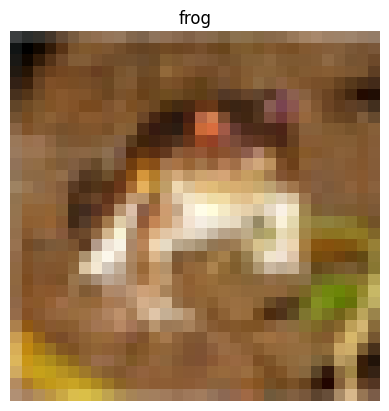

In [3]:
class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

plt.imshow(X_train[0])
plt.title(class_names[y_train[0][0]])
plt.axis('off')
plt.show()

In [4]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [5]:
model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

model.add(Conv2D(128, (3,3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [7]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=64,
    validation_data=(X_test, y_test)
)

Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 165s 206ms/step - accuracy: 0.4178 - loss: 1.6233 - val_accuracy: 0.5539 - val_loss: 1.2304
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 156s 200ms/step - accuracy: 0.5724 - loss: 1.2184 - val_accuracy: 0.4769 - val_loss: 1.5994
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 158s 202ms/step - accuracy: 0.6393 - loss: 1.0394 - val_accuracy: 0.6305 - val_loss: 1.0692
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 203s 204ms/step - accuracy: 0.6840 - loss: 0.9188 - val_accuracy: 0.6673 - val_loss: 0.9819
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 157s 201ms/step - accuracy: 0.7138 - loss: 0.8252 - val_accuracy: 0.6903 - val_loss: 0.9329
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 201s 200ms/step - accuracy: 0.7402 - loss: 0.7532 - val_accuracy: 0.7210 - val_loss: 0.8045
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 158s 201ms/step - accuracy: 0.7626 - loss: 0.6882 - val_accuracy: 0.7473 - val_loss: 0.7565
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 162s 207ms/step - accuracy: 0.7808 -

In [8]:
loss, acc = model.evaluate(X_test, y_test)
print("Accuracy:", acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 0.7565 - loss: 0.9959
Accuracy: 0.7565000057220459


313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step


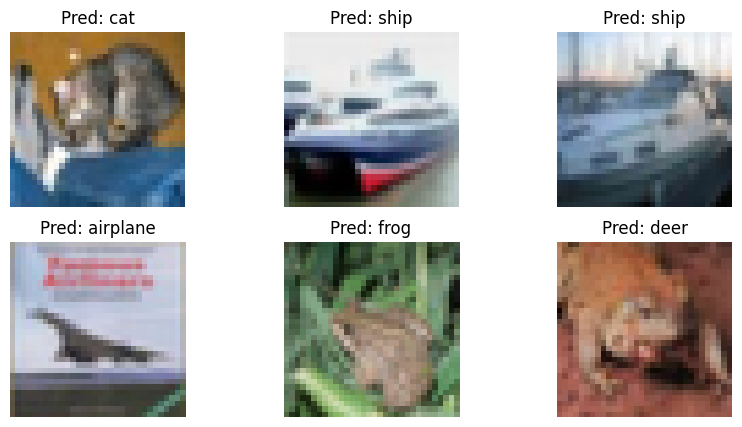

In [9]:
# Class names
class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

# Predict
predictions = model.predict(X_test)

# Show some predictions
plt.figure(figsize=(10,5))

for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(X_test[i])
    plt.title("Pred: " + class_names[np.argmax(predictions[i])])
    plt.axis('off')

plt.show()